# Libraries

In [8]:
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update({
                        'font.family': 'serif',
                        'mathtext.fontset': 'cm',
                        'axes.unicode_minus': False
                    })
import numpy as np
import pandas as pd
import seaborn as sns
import scipy as sci
from sklearn.metrics import r2_score

# Dataset upload and computing error model

In [9]:
data = pd.read_excel(r'C:\git-projetos\2025-2_andre_rimes\gen_dataset\data_models_rv2.xlsx', sheet_name='Modelos')
data.columns = data.columns.str.lower().str.replace(' ', '-')
data['wnum/wexp'] = data['fib-model-code-2020--com-ts-variável-(mm)'] / data['output:-w_exp-(mm)']
data.head()

,autor,output:-w_exp-(mm),fib-model-code-2020-(mm),wexp_menos_wfib2020,fib-model-code-2020--com-ts-variável-(mm),wexp_menos_wfib2020ts,norma-chinesa-(mm),wnum/wexp
0,Viga S200-1.76-20 - Sokolov et al (2021),0.16,0.086159,0.073841,0.102130,0.057870,NaN,0.638311
1,NaN,0.23,0.147127,0.082873,0.190783,0.039217,NaN,0.829489
2,NaN,0.24,0.155568,0.084432,0.203058,0.036942,NaN,0.846073
3,NaN,0.27,0.196838,0.073162,0.263069,0.006931,NaN,0.974328
4,NaN,0.35,0.277502,0.072498,0.380363,-0.030363,NaN,1.086752


### Mean and standard deviation

In [10]:
data.describe()

,output:-w_exp-(mm),fib-model-code-2020-(mm),wexp_menos_wfib2020,fib-model-code-2020--com-ts-variável-(mm),wexp_menos_wfib2020ts,norma-chinesa-(mm),wnum/wexp
count,341.000000,341.000000,341.000000,341.000000,341.000000,0.0,341.000000
mean,0.261672,0.214851,0.046821,0.266323,-0.004652,NaN,1.053564
std,0.115072,0.082905,0.073870,0.117894,0.089706,NaN,0.367786
min,0.140000,0.052197,-0.126383,0.052197,-0.255521,NaN,0.260985
25%,0.190000,0.156100,0.000735,0.178993,-0.062509,NaN,0.798741
50%,0.230000,0.205276,0.037442,0.250469,0.002474,NaN,0.991865
75%,0.300000,0.261428,0.082873,0.330521,0.053210,NaN,1.268263
max,0.790000,0.514251,0.323894,0.701453,0.266758,NaN,2.191049


### $R^2$

In [11]:
obs = data['output:-w_exp-(mm)']
pred = data['fib-model-code-2020--com-ts-variável-(mm)']
r2_fib_model_2020 = r2_score(obs, pred)
r2_fib_model_2020

0.39064274559226597

# Charts

In [12]:
name = 'fib_model_2020ts'

### Predict versus Experimental

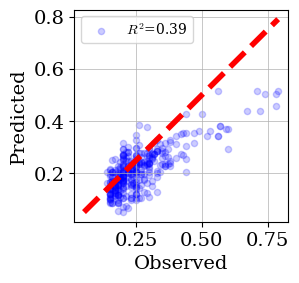

In [13]:
dpi = 600               # Change as you wish
b_cm = 7                       # Change as you wish
h_cm = 7                        # Change as you wish
inches_to_cm = 1 / 2.54
b_input = b_cm * inches_to_cm
h_input = h_cm * inches_to_cm
label_x = 'Observed'            # Change as you wish
label_y = 'Predicted'           # Change as you wish
size_label = 14                 # Change as you wish
color_label = 'black'            # or hexadecimal. Change as you wish
size_axis = 14                  # Change as you wish
color_axis = 'black'              # or hexadecimal. Change as you wish
size_line = 4           # Change as you wish
style_line = '--'       # Change as you wish
color_line = 'red'      # or hexadecimal. Change as you wish
labels_legend = [rf'$R^2$={r2_fib_model_2020:.2f}']   # Change as you wish
size_legend = 10                # Change as you wish
location_legend = 'upper left'  # Change as you wish - 'best' look up by the best fit
fig, ax = plt.subplots(figsize=(b_input, h_input))
lims = [
            min(data['output:-w_exp-(mm)'].min(), data['fib-model-code-2020-(mm)'].min()),
            max(data['output:-w_exp-(mm)'].max(), data['fib-model-code-2020-(mm)'].max())
        ]

# Config axis
ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)
ax.set_xlabel(label_x, fontsize=size_label, color=color_label)
ax.set_ylabel(label_y, fontsize=size_label, color=color_label)

# Config grid
on_or_off = True
plt.grid(on_or_off, which='both', linestyle='-', linewidth=0.5)

# Plot data y = x and scatter
ax.plot(lims, lims, linewidth=size_line, linestyle=style_line, color=color_line,)
ax.scatter(data["output:-w_exp-(mm)"], data["fib-model-code-2020-(mm)"], alpha=0.2, color='blue', s=20, label=labels_legend[0])
ax.legend(fontsize=size_legend, loc=location_legend)

# Save. Do you need save? Use the cell bellow:
fig.savefig(f'z_scatter-line_{name}.png', dpi=dpi, bbox_inches='tight')
plt.show()

### KDE numerical model - original model

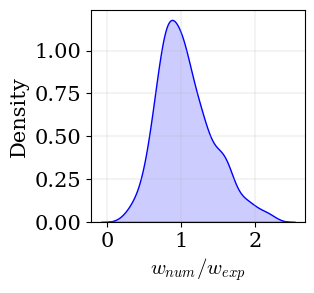

In [14]:
dpi = 600               

b_cm = 7            
h_cm = 7
inches_to_cm = 1 / 2.54
b_input = b_cm * inches_to_cm
h_input = h_cm * inches_to_cm

label_y = 'Density'
label_x = '$w_{num}/w_{exp}$'   
size_label = 15
color_label = 'black'
size_axis = 15
color_axis = 'black'           

labels_legend = ['fib Model 2020']   
size_legend = 9                
location_legend = 'upper right'  

fig, ax = plt.subplots(figsize=(b_input, h_input))
ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)
ax.set_xlabel(label_x, fontsize=size_label, color=color_label)
ax.set_ylabel(label_y, fontsize=size_label, color=color_label)
on_or_off = True
plt.grid(on_or_off, which='both', linestyle='-', linewidth=0.2)
sns.kdeplot(data=data, x='wnum/wexp', fill=True, alpha=0.2, color='blue', ax=ax, label=labels_legend[0])
# ax.legend(fontsize=size_legend, loc=location_legend)
fig.savefig(f'z_kde_{name}.png', dpi=dpi, bbox_inches='tight')
plt.show()

# Goodness-of-fit

### Anderson-Darling test

Normal

In [15]:
# alpha = 5
# res = sci.stats.anderson(np.log(data['wnum/wexp']), dist="norm")
# stat = res.statistic
# crit = res.critical_values[res.significance_level == alpha][0]
# decision = "Accepted" if stat < crit else "Rejected"
# print(f"AD Statistic: {stat:.4f}")
# print(f"Critical Value at {alpha}% significance level: {crit:.4f}")
# print(f"Null Hypothesis: {decision}")

### Kolmogorov-Smirnov test

t-student

In [16]:
x = data['wnum/wexp'].values
df, loc, scale = sci.stats.t.fit(x)
print(f"\nFitted Student-t parameters:\nDegrees of freedom: {df:.4f}, Location: {loc:.4f}, Scale: {scale:.4f}")
ks_stat, ks_p = sci.stats.kstest(x, 't', args=(df, loc, scale))
print("\nKolmogorov-Smirnov Test for Student-t Distribution:")
print(f"Student-t KS statistic: {ks_stat:.4f}")
print(f"p-value: {ks_p:.4f}")


Fitted Student-t parameters:
Degrees of freedom: 18.2849, Location: 1.0413, Scale: 0.3469

Kolmogorov-Smirnov Test for Student-t Distribution:
Student-t KS statistic: 0.0777
p-value: 0.0307


Normal

In [17]:
x = data['wnum/wexp'].values
loc, scale = sci.stats.norm.fit(x)
print(f"\nFitted Normal parameters:\nLocation: {loc:.4f}, Scale: {scale:.4f}")
ks_stat, ks_p = sci.stats.kstest(x, 'norm', args=(loc, scale))
print("\nKolmogorov-Smirnov Test for Normal Distribution:")
print(f"Normal KS statistic: {ks_stat:.4f}")
print(f"p-value: {ks_p:.4f}")


Fitted Normal parameters:
Location: 1.0536, Scale: 0.3672

Kolmogorov-Smirnov Test for Normal Distribution:
Normal KS statistic: 0.0935
p-value: 0.0048


Log-normal

In [18]:
x = data['wnum/wexp'].values
shape, loc, scale = sci.stats.lognorm.fit(x)
print(f"\nFitted Lognormal parameters:\nShape: {shape:.4f}, Location: {loc:.4f}, Scale: {scale:.4f}")
ks_stat, ks_p = sci.stats.kstest(x, 'lognorm', args=(shape, loc, scale))
print("\nKolmogorov-Smirnov Test for Lognormal Distribution:")
print(f"Lognormal KS statistic: {ks_stat:.4f}")
print(f"p-value: {ks_p:.4f}")


Fitted Lognormal parameters:
Shape: 0.2533, Location: -0.3775, Scale: 1.3859

Kolmogorov-Smirnov Test for Lognormal Distribution:
Lognormal KS statistic: 0.0439
p-value: 0.5135


### Genetate statistics for Lognormal

In [19]:
mu = np.log(scale)
sigma = shape

mean = loc + np.exp(mu + 0.5*sigma**2)
var = (np.exp(sigma**2) - 1) * np.exp(2*mu + sigma**2)
std = np.sqrt(var)

print("\nLognormal Distribution Moments after fitting:")
print(f"Mean = {mean:.3f}")
print(f"Std  = {std:.3f}")


Lognormal Distribution Moments after fitting:
Mean = 1.054
Std  = 0.368


#### Generate synthetic data

In [20]:
sigma = np.sqrt(np.log(1 + (std / mean)**2))
mu = np.log(mean) - 0.5 * sigma**2

shape = sigma
loc = 0.0
scale = np.exp(mu)

print(f"shape = {shape:.4f}")
print(f"loc   = {loc:.4f}")
print(f"scale = {scale:.4f}")

n_samples = 20000
synthetic_data = sci.stats.lognorm.rvs(s=shape, loc=loc, scale=scale, size=n_samples)

shape = 0.3396
loc   = 0.0000
scale = 0.9946


In [21]:
# Double check the fit on the synthetic data
x = synthetic_data.copy()
shape, loc, scale = sci.stats.lognorm.fit(x)
print(f"\nFitted Lognormal parameters:\nShape: {shape:.4f}, Location: {loc:.4f}, Scale: {scale:.4f}")
ks_stat, ks_p = sci.stats.kstest(x, 'lognorm', args=(shape, loc, scale))
print("\nKolmogorov-Smirnov Test for Lognormal Distribution:")
print(f"Lognormal KS statistic: {ks_stat:.4f}")
print(f"p-value: {ks_p:.4f}")


Fitted Lognormal parameters:
Shape: 0.3382, Location: -0.0114, Scale: 1.0075

Kolmogorov-Smirnov Test for Lognormal Distribution:
Lognormal KS statistic: 0.0029
p-value: 0.9967


#### Synthetic data versus original data

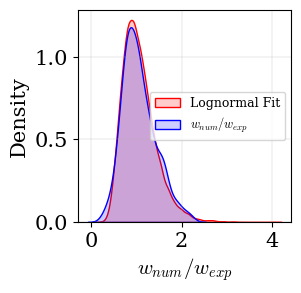

In [22]:
fig, ax = plt.subplots(figsize=(b_input, h_input))
ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)
ax.set_xlabel(label_x, fontsize=size_label, color=color_label)
ax.set_ylabel(label_y, fontsize=size_label, color=color_label)
on_or_off = True
plt.grid(on_or_off, which='both', linestyle='-', linewidth=0.2)
sns.kdeplot(data=synthetic_data, fill=True, alpha=0.2, color='red', label='Lognormal Fit', ax=ax)
sns.kdeplot(data=list(data['wnum/wexp']), fill=True, alpha=0.2, color='blue', label='$w_{num}/w_{exp}$', ax=ax)
ax.legend(fontsize=size_legend, loc='center right')
fig.savefig(f'z_kde_{name}_gt_versus_lognormal.png', dpi=dpi, bbox_inches='tight')
plt.show()